**Membros do grupo:**
* Ana Luiza Macêdo dos Santos [matrícula]
* Hector Julio Pardinho Soares [matrícula]
* Laura Godinho Barroso [matrícula]
* Mariane Mara de Souza [matrícula]
* Salvador Cândido da Silva Júnior [matrícula]

In [1]:
import pandas as pd
import pysubgroup as ps
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Business Understanding

# 2. Data Understanding

In [ ]:
raw_data_07 = pd.read_csv('datatran2007.csv', encoding='latin-1', sep=';')
raw_data_07.head()

In [3]:

raw_data_25 = pd.read_csv('datatran2025.csv', encoding='latin-1', sep=';')
raw_data_25.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,...,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,...,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,...,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [4]:
def missing_values_of_dataset(df):
    """Prints missing values for a dataframe."""

    print("==================================================")
    print("1. MISSING VALUES & INFOS PER COLUMN")
    print("==================================================")
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.DataFrame(
        {"Missing Count": missing_count, "Percentage (%)": missing_pct}
    )
    print(missing_df.to_string())
    print("\n")

In [5]:
missing_values_of_dataset(raw_data_25)

1. MISSING VALUES & INFOS PER COLUMN
                        Missing Count  Percentage (%)
id                                  0        0.000000
data_inversa                        0        0.000000
dia_semana                          0        0.000000
horario                             0        0.000000
uf                                  0        0.000000
br                                  0        0.000000
km                                  0        0.000000
municipio                           0        0.000000
causa_acidente                      0        0.000000
tipo_acidente                       0        0.000000
classificacao_acidente              1        0.001379
fase_dia                            0        0.000000
sentido_via                         0        0.000000
condicao_metereologica              0        0.000000
tipo_pista                          0        0.000000
tracado_via                         0        0.000000
uso_solo                            0        

In [6]:
def plotar_contagem_categorica(
    df, coluna, titulo=None, cor="skyblue", top_n=None, ax=None
):
    """Gera um gráfico de barras com a contagem absoluta e o percentual de uma variável.

    Pode ser usada individualmente ou dentro de uma grade de múltiplos gráficos.
    """
    if coluna not in df.columns:
        print(f"Erro: A coluna '{coluna}' não existe no DataFrame.")
        return

    dados_filtrados = df[coluna].dropna().astype(str)
    total_registros = len(dados_filtrados)

    if total_registros == 0:
        return

    ordem_categorias = dados_filtrados.value_counts().index
    if top_n is not None:
        ordem_categorias = ordem_categorias[:top_n]

    # SE ESTIVERMOS PLOTANDO LADO A LADO, USAMOS O AX PASSADO.
    # CASO CONTRÁRIO, CRIAMOS UMA FIGURA NOVA (COMPATIBILIDADE).
    if ax is None:
        plt.figure(figsize=(10, 6))
        sns.set_theme(style="whitegrid")
        ax = plt.gca()

    # Cria o gráfico de barras associando ao eixo específico (ax)
    sns.countplot(
        data=df,
        x=coluna,
        order=ordem_categorias,
        color=cor,
        edgecolor="black",
        linewidth=0.7,
        ax=ax,
    )

    # Configurações de títulos e rótulos no eixo atual
    titulo_grafico = titulo if titulo else f"Distribuição: {coluna}"
    ax.set_title(titulo_grafico, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel(coluna.replace("_", " ").title(), fontsize=10, labelpad=8)
    ax.set_ylabel("Contagem (Frequência)", fontsize=10, labelpad=8)

    # Rotaciona rótulos do eixo X
    current_ticks = ax.get_xticks()
    current_labels = [label.get_text() for label in ax.get_xticklabels()]
    ax.set_xticks(current_ticks)
    ax.set_xticklabels(
        current_labels, rotation=45, ha="right", fontsize=9
    )

    # Adiciona rótulos com Contagem e Percentual no topo de cada barra
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            percentual = (altura / total_registros) * 100
            label = f"{int(altura)}\n({percentual:.1f}%)"  # \n quebra a linha para ficar mais compacto

            ax.annotate(
                label,
                (p.get_x() + p.get_width() / 2.0, altura),
                ha="center",
                va="center",
                xytext=(0, 10),
                textcoords="offset points",
                fontsize=8.5,
                fontweight="semibold",
            )

    # Margem de segurança no topo do gráfico atual
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

    # Se a função foi chamada individualmente, mostra o gráfico
    if ax == plt.gca() and ax.figure.images == []:
        plt.tight_layout()
        plt.show()

In [7]:
def plotar_multiplos_categoricos(df, colunas, n_colunas=3, top_n=8):
    """Cria um único canvas com múltiplos gráficos de contagem organizados em uma grade.

    Parâmetros:
    - df: DataFrame do Pandas.
    - colunas: Lista de strings com os nomes das colunas categóricas.
    - n_colunas: Quantidade de gráficos que ficarão lado a lado (padrão: 3).
    - top_n: Limite de categorias principais exibidas por gráfico.
    """
    n_graficos = len(colunas)

    # Calcula automaticamente quantas linhas serão necessárias para acomodar os k gráficos
    n_linhas = math.ceil(n_graficos / n_colunas)

    # Define o tamanho dinâmico do canvas (largura fixa proporcional, altura expande por linha)
    fig, eixos = plt.subplots(
        nrows=n_linhas,
        ncols=n_colunas,
        figsize=(6 * n_colunas, 5 * n_linhas),
        squeeze=False,
    )
    sns.set_theme(style="whitegrid")

    # Transforma a matriz de eixos em uma lista achatada (1D) para iterar facilmente
    eixos_achatados = eixos.flatten()

    # Paleta de cores para os subplots não ficarem todos iguais
    cores = sns.color_palette("Set2", n_graficos)

    # Plota cada variável em seu respectivo quadrante
    for i, coluna in enumerate(colunas):
        plotar_contagem_categorica(
            df=df,
            coluna=coluna,
            cor=cores[i],
            top_n=top_n,
            ax=eixos_achatados[i],  # Passa o quadrante específico
        )

    # Esconde os eixos vazios que sobrarem na grade (ex: pedir 5 gráficos em uma grade de 3x2)
    for j in range(i + 1, len(eixos_achatados)):
        fig.delaxes(eixos_achatados[j])

    # Ajusta o espaçamento para que as legendas de um gráfico não entrem no outro
    plt.tight_layout()
    plt.show()

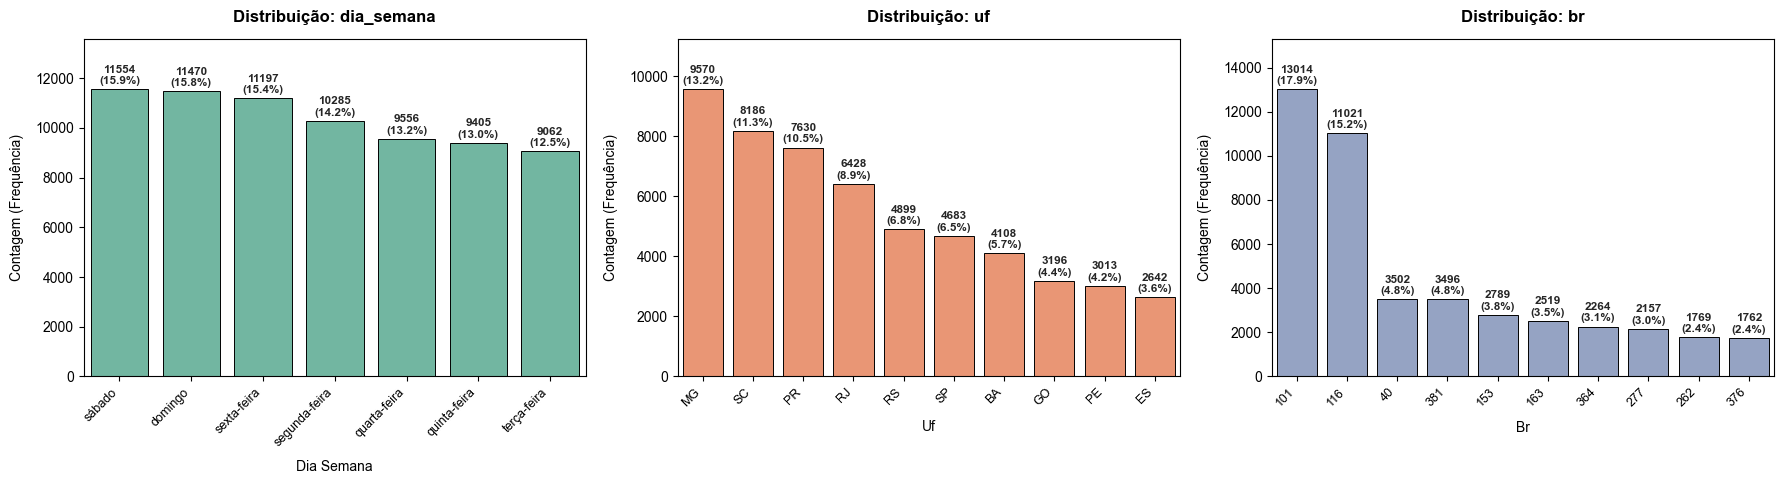

<Figure size 640x480 with 0 Axes>

In [8]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_1 = [
    "dia_semana",
    "uf",
    "br"
]

# Chama a função mestre para plotar em um grid de 3 colunas
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_1, n_colunas=3, top_n=10)

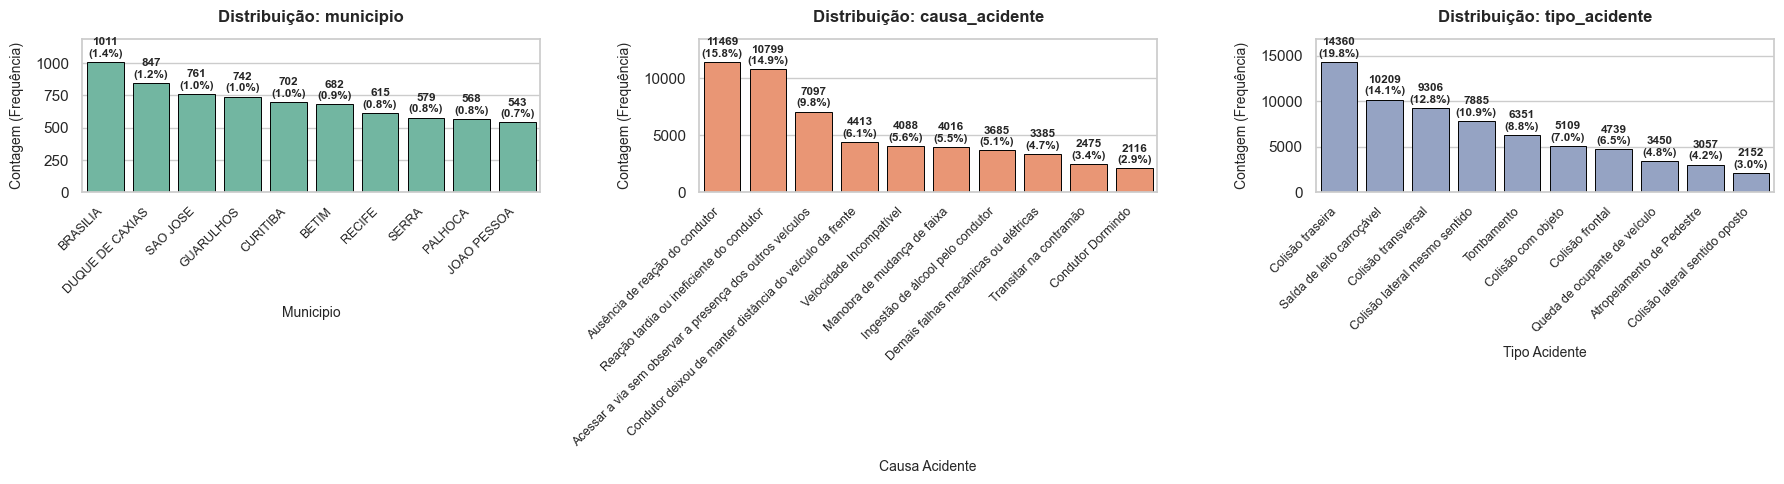

<Figure size 640x480 with 0 Axes>

In [9]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_2 = [
    'municipio',
    'causa_acidente',
    'tipo_acidente'
]

# Chama a função mestre para plotar em um grid de 3 colunas
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_2, n_colunas=3, top_n=10)

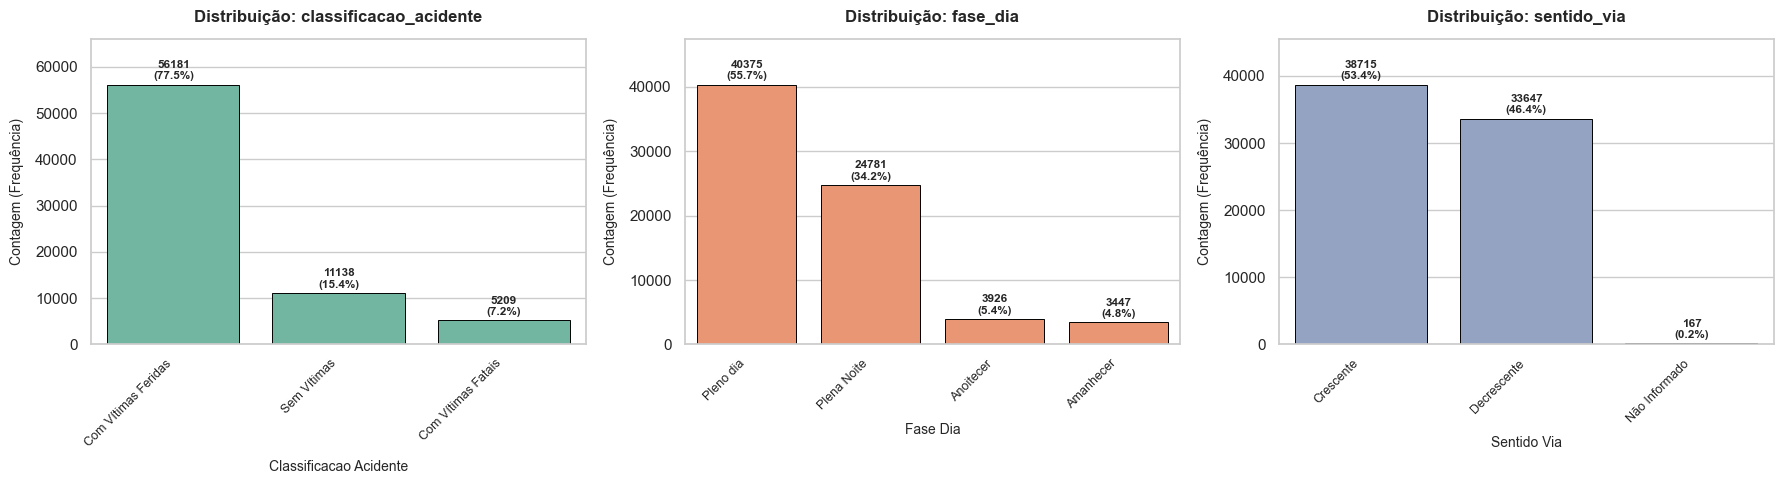

<Figure size 640x480 with 0 Axes>

In [10]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_3 = [
    'classificacao_acidente',
    'fase_dia',
    'sentido_via'
]

# Chama a função mestre para plotar em um grid de 3 colunas
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_3, n_colunas=3, top_n=10)

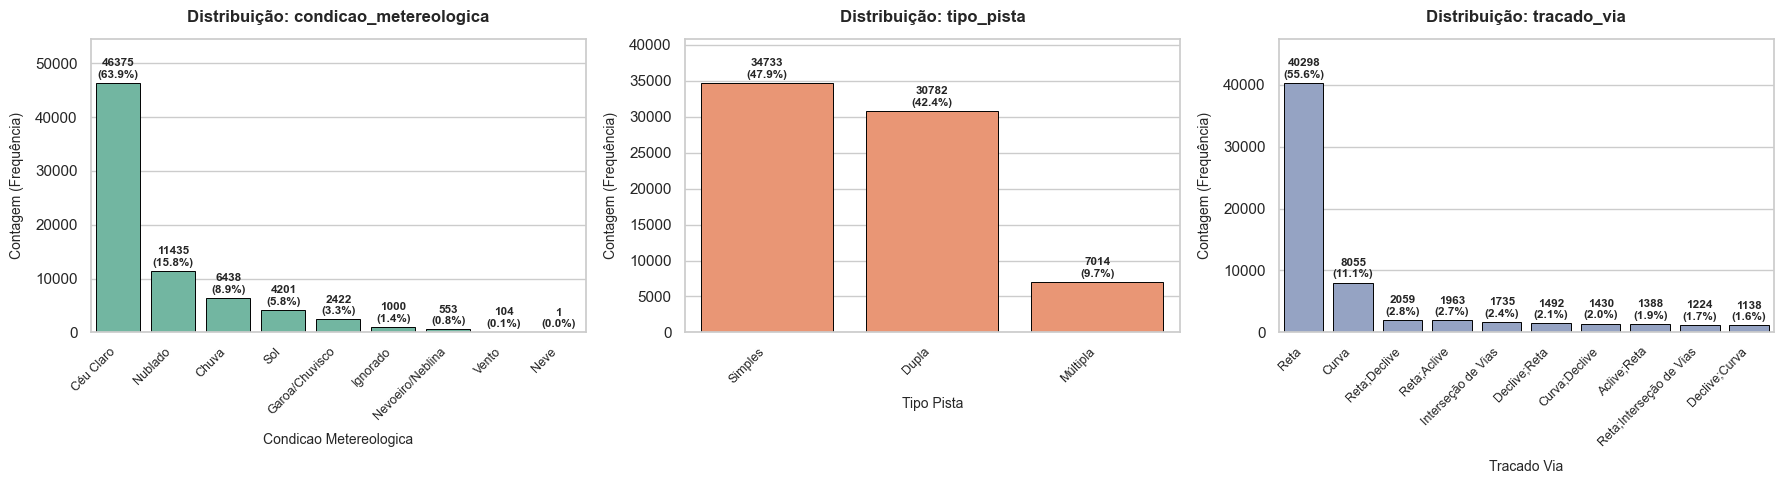

<Figure size 640x480 with 0 Axes>

In [11]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_4 = [
    'condicao_metereologica',
    'tipo_pista',
    'tracado_via'
]

# Chama a função mestre para plotar em um grid de 3 colunas
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_4, n_colunas=3, top_n=10)

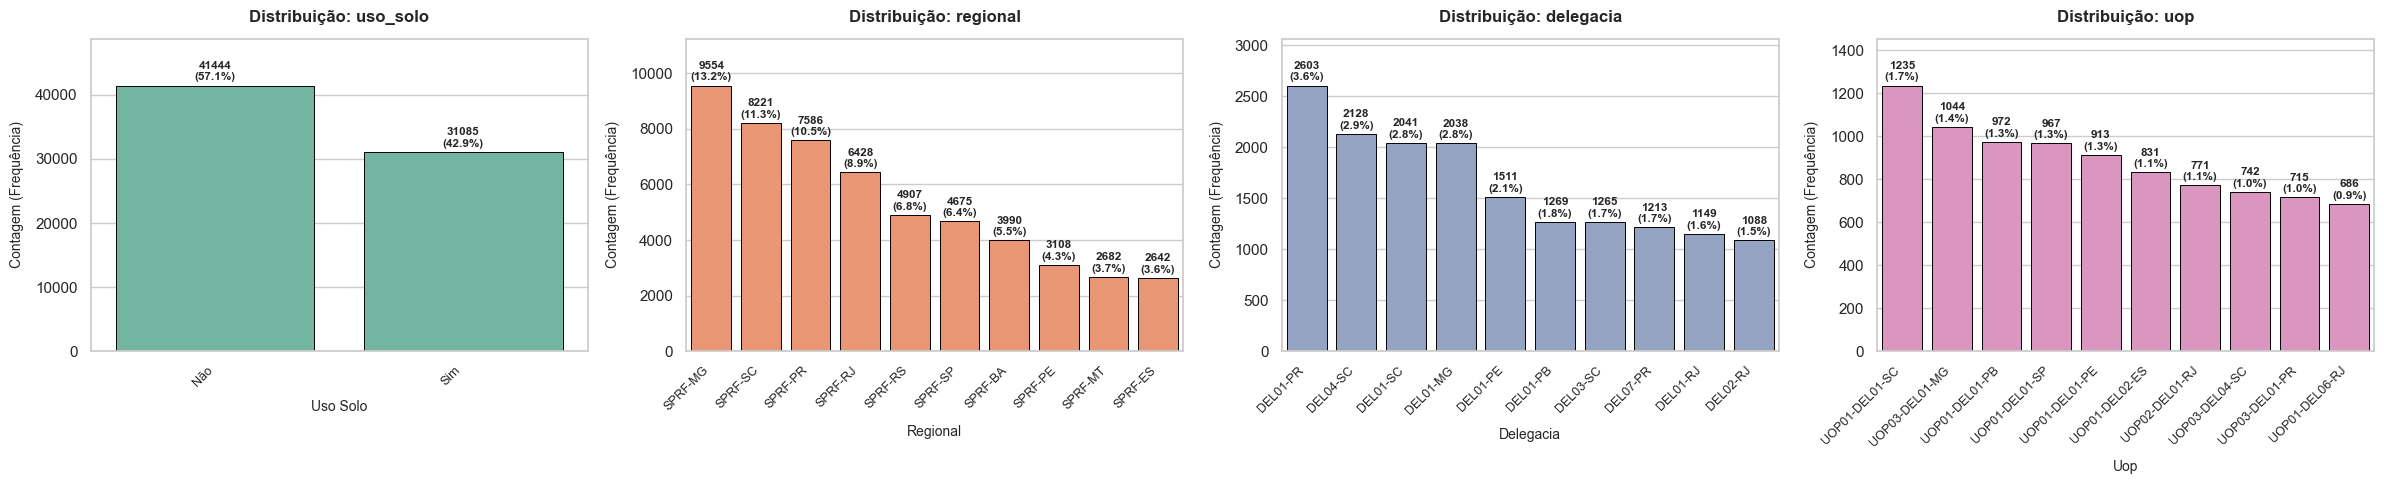

<Figure size 640x480 with 0 Axes>

In [12]:
# Lista de colunas que você quer colocar lado a lado
minhas_variaveis_5 = [
    'uso_solo',
    'regional',
    'delegacia',
    'uop'
]

# Chama a função mestre para plotar em um grid de 3 colunas
plotar_multiplos_categoricos(df=raw_data_25, colunas=minhas_variaveis_5, n_colunas=4, top_n=10)

# 3. Data Preparation

In [13]:

colunas_em_comum = ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km','municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 
    'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 
    'feridos', 'veiculos'
]

df07 = raw_data_07[colunas_em_comum]                
df25 = raw_data_25[colunas_em_comum]



def preprocess(df):
    df = df.copy()

    # Target binário: acidente com vítima fatal
    df['fatal'] = (df['mortos'] > 0).astype(int)

    # Turno do dia a partir do horário
    df['horario'] = df['horario'].astype(str).str[:2]
    df['horario'] = pd.to_numeric(df['horario'], errors='coerce')
    df['turno'] = pd.cut(
        df['horario'],
        bins=[-1, 5, 11, 17, 23],
        labels=['madrugada', 'manha', 'tarde', 'noite']
    )

    # Colunas categóricas que usaremos como features
    cats = [
        'dia_semana', 'uf', 'causa_acidente', 'tipo_acidente',
        'fase_dia', 'condicao_metereologica', 'tipo_pista',
        'tracado_via', 'uso_solo', 'turno'
    ]
    for c in cats:
        df[c] = df[c].astype(str).str.strip().str.lower()

    df = df.dropna(subset=['fatal'] + cats)
    return df, cats

df07_clean, cats = preprocess(df07)
df25_clean, _    = preprocess(df25)

# 4. Modeling

In [14]:
def run_sd(df, cats, target_col='fatal', top_k=20, depth=3):
    """Retorna top-K subgrupos ordenados por WRAcc."""
    target = ps.BinaryTarget(target_col, True)

    searchspace = ps.create_selectors(df, ignore=[target_col])
    # Filtra para usar só as colunas categóricas que preparamos
    searchspace = [s for s in searchspace
                   if any(c in str(s) for c in cats)]

    task = ps.SubgroupDiscoveryTask(
        df,
        target,
        searchspace,
        result_set_size=top_k,
        depth=depth,
        qf=ps.WRAccQF()          # Weighted Relative Accuracy
    )

    with np.errstate(divide='ignore', invalid='ignore'):
        result = ps.BeamSearch().execute(task)
    return result.to_dataframe()

print("Rodando SD em 2007...")
res07 = run_sd(df07_clean, cats)

print("Rodando SD em 2025...")
res25 = run_sd(df25_clean, cats)

Rodando SD em 2007...
Rodando SD em 2025...


# 5. Evaluation

In [15]:
def subgroup_to_str(sg):
    return str(sg).strip().lower()

# Mapeia string -> linha original para recuperar métricas
map07 = {subgroup_to_str(r['subgroup']): r for _, r in res07.iterrows()}
map25 = {subgroup_to_str(r['subgroup']): r for _, r in res25.iterrows()}

set07 = set(map07.keys())
set25 = set(map25.keys())

jaccard = len(set07 & set25) / len(set07 | set25) if set07 | set25 else 0

def make_table(keys, map_principal, map_secundario=None):
    rows = []
    for k in sorted(keys):
        r = map_principal[k]
        row = {
            'subgrupo': k,
            'quality':  round(r['quality'], 4),
            'tamanho':  int(r['size_sg']),
            'p(fatal)': round(r['target_share_sg'], 4),
        }
        if map_secundario and k in map_secundario:
            r2 = map_secundario[k]
            row['quality_outro_ano'] = round(r2['quality'], 4)
            row['p(fatal)_outro_ano'] = round(r2['target_share_sg'], 4)
        rows.append(row)
    return pd.DataFrame(rows)

df_persistentes = make_table(set07 & set25, map07, map25)
df_novos        = make_table(set25 - set07, map25)
df_extintos     = make_table(set07 - set25, map07)

# Renomeia colunas dos persistentes para deixar claro qual ano é qual
df_persistentes = df_persistentes.rename(columns={
    'quality':           'quality_2007',
    'tamanho':           'tamanho_2007',
    'p(fatal)':          'p(fatal)_2007',
    'quality_outro_ano': 'quality_2025',
    'p(fatal)_outro_ano':'p(fatal)_2025',
})

sep = "-" * 60

print(f"\n{'=' * 60}")
print(f"  COMPARAÇÃO TEMPORAL  |  Jaccard: {jaccard:.2f}")
print(f"{'=' * 60}")

print(f"\n── PERSISTENTES ({len(df_persistentes)}) ─────────────────────────────")
print(df_persistentes.to_string(index=False))

print(f"\n── NOVOS em 2025 ({len(df_novos)}) ──────────────────────────────────")
print(df_novos.to_string(index=False))

print(f"\n── EXTINTOS desde 2007 ({len(df_extintos)}) ─────────────────────────")
print(df_extintos.to_string(index=False))

print(f"\n{sep}")
print(f"  Persistentes: {len(df_persistentes):>3}  |  "
      f"Novos: {len(df_novos):>3}  |  "
      f"Extintos: {len(df_extintos):>3}")
print(sep)


  COMPARAÇÃO TEMPORAL  |  Jaccard: 0.18

── PERSISTENTES (6) ─────────────────────────────
                                                  subgrupo  quality_2007  tamanho_2007  p(fatal)_2007  quality_2025  p(fatal)_2025
                                   fase_dia=='plena noite'        0.0064         42871         0.0618        0.0102         0.1018
         fase_dia=='plena noite' and tipo_pista=='simples'        0.0063         24751         0.0751        0.0101         0.1315
                          tipo_acidente=='colisão frontal'        0.0077          4581         0.2565        0.0146         0.2946
tipo_acidente=='colisão frontal' and tipo_pista=='simples'        0.0073          3999         0.2761        0.0141         0.3128
                                     tipo_pista=='simples'        0.0069         71637         0.0548        0.0128         0.0986
             tipo_pista=='simples' and tracado_via=='reta'        0.0062         48402         0.0589        0.0079       

In [16]:
res07['ano'] = 2007
res25['ano'] = 2025
comparativo = pd.concat([res07, res25], ignore_index=True)
comparativo.to_csv("subgrupos_comparativo.csv", index=False)

print("\nTop 5 subgrupos 2007:")
print(res07[['subgroup', 'quality', 'size_sg', 'target_share_sg']].head())
print("\nTop 5 subgrupos 2025:")
print(res25[['subgroup', 'quality', 'size_sg', 'target_share_sg']].head())


Top 5 subgrupos 2007:
                                            subgroup   quality  size_sg  \
0        tipo_pista=='simples' AND uso_solo=='rural'  0.007717    46440   
1                   tipo_acidente=='colisão frontal'  0.007674     4581   
2  tipo_acidente=='colisão frontal' AND tipo_pist...  0.007312     3999   
3                              tipo_pista=='simples'  0.006851    71637   
4           tipo_acidente=='atropelamento de pessoa'  0.006821     3852   

   target_share_sg  
0         0.063824  
1         0.256494  
2         0.276069  
3         0.054818  
4         0.268692  

Top 5 subgrupos 2025:
                                            subgroup   quality  size_sg  \
0          tipo_pista=='simples' AND uso_solo=='não'  0.015581    23860   
1                   tipo_acidente=='colisão frontal'  0.014554     4739   
2  tipo_acidente=='colisão frontal' AND tipo_pist...  0.014073     4236   
3  tipo_acidente=='colisão frontal' AND uso_solo=...  0.012943     3359   
4 